In [19]:
import matplotlib.pyplot as plt
import math

class PlotCollector:
    def __init__(self):
        self.jobs = []

    def add(self, plot_fn, *args, label=None, **kwargs):
        self.jobs.append({
            "fn": plot_fn,
            "args": args,
            "kwargs": kwargs,
            "label": label
        })

    def render(self, layout="grid", ncols=2, sharex=False, sharey=False):
        n = len(self.jobs)

        if layout == "grid":
            nrows = math.ceil(n / ncols)
        elif layout == "column":
            ncols, nrows = 1, n
        elif layout == "row":
            ncols, nrows = n, 1
        else:
            raise ValueError("unknown layout")

        fig, axes = plt.subplots(nrows, ncols,
                                 figsize=(5*ncols, 4*nrows),
                                 squeeze=False,
                                 sharex=sharex, sharey=sharey)

        axes = axes.flatten()

        for i, job in enumerate(self.jobs):
            ax = axes[i]
            job["fn"](ax, *job["args"], **job["kwargs"])

            if job["label"] is not None:
                ax.set_title(job["label"])

        # remove unused axes
        for j in range(i+1, len(axes)):
            fig.delaxes(axes[j])

        return fig

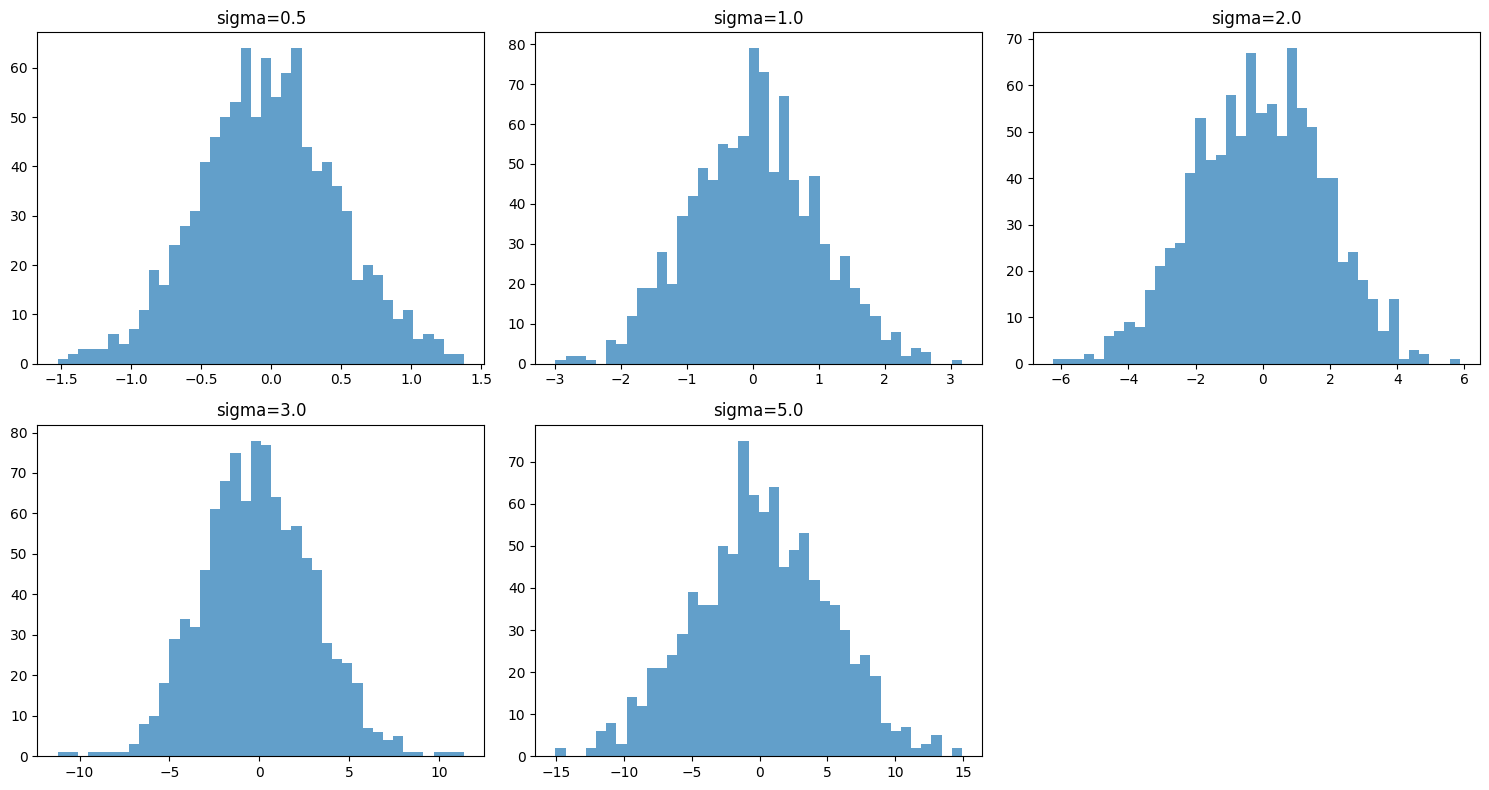

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# simple plotting fn
def plot_hist(ax, data, bins=30, alpha=0.7):
    ax.hist(data, bins=bins, alpha=alpha)

# test run
collector = PlotCollector()

np.random.seed(0)

for i, sigma in enumerate([0.5, 1.0, 2.0, 3.0, 5.0]):
    data = np.random.normal(loc=0.0, scale=sigma, size=1000)
    collector.add(plot_hist, data, bins=40, label=f"sigma={sigma}")

fig = collector.render(layout="grid", ncols=3)
plt.tight_layout()
plt.show()